<a href="https://colab.research.google.com/github/aisha13dikko-sudo/using-synthetic-data-for-thermal-comfort-classification/blob/main/wk2_gaussian_copula.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install sdv datasets --quiet
print("✅ Installation complete!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.2/15.2 MB 111.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 100.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 9.1 MB/s eta 0:00:00
✅ Installation complete!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset
from sdv.single_table import GaussianCopulaSynthesizer
from sdv.metadata import SingleTableMetadata
from sdv.evaluation.single_table import evaluate_quality

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (f1_score, balanced_accuracy_score,
                             classification_report)
from sklearn.preprocessing import LabelEncoder

print("✅ All imports ready!")

✅ All imports ready!


In [ ]:
# Load AutoTherm indoor dataset
print("Loading AutoTherm indoor dataset...")
dataset = load_dataset('kopetri/AutoTherm', 'indoor')
train_df = dataset['train'].to_pandas()
print(f"Loaded {len(train_df):,} rows")

# Extract participant ID
import re
def extract_participant_id(filename):
    match = re.search(r'participant_\d+', filename)
    return match.group() if match else 'unknown'

train_df['participant_id'] = train_df['file_name'].apply(extract_participant_id)

# Add 3-class label
def add_3class(df):
    df = df.copy()
    df['Label_3class'] = df['Label'].apply(
        lambda x: -1 if x <= -2 else (0 if x <= 1 else 1)
    )
    return df

train_df = add_3class(train_df)

# Subject-wise split
test_participants  = ['participant_16', 'participant_14', 'participant_20']
train_participants = [p for p in train_df['participant_id'].unique()
                      if p not in test_participants]

train_split = train_df[train_df['participant_id'].isin(train_participants)]
test_split  = train_df[train_df['participant_id'].isin(test_participants)]

print(f"Train: {len(train_split):,} rows | Test: {len(test_split):,} rows")
print(f"✅ Subject-wise split clean!")

Loading AutoTherm indoor dataset...


README.md:   0%|          | 0.00/8.57k [00:00<?, ?B/s]

indoor/train-00000-of-00002.parquet:   0%|          | 0.00/29.8M [00:00<?, ?B/s]

indoor/train-00001-of-00002.parquet:   0%|          | 0.00/30.0M [00:00<?, ?B/s]

indoor/test-00000-of-00001.parquet:   0%|          | 0.00/7.41M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1566728 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/194829 [00:00<?, ? examples/s]

Loaded 1,566,728 rows
Train: 1,276,709 rows | Test: 290,019 rows
✅ Subject-wise split clean!


In [ ]:
# Columns we drop — identifiers, zero variance, pose keypoints
drop_cols = [
    'file_name', 'Timestamp', 'participant_id',
    'Air-Velocity', 'Metabolic-Rate',
    'Nose', 'Neck', 'RShoulder', 'RElbow',
    'LShoulder', 'LElbow', 'REye', 'LEye', 'REar', 'LEar',
    'Emotion-Self', 'Emotion-ML',
    'Label', 'Label_3class'   # always drop BOTH label columns
]

# Feature preparation function
def prepare_features(df, drop_cols, target_col):
    df = df.copy()
    X = df.drop(columns=drop_cols, errors='ignore')
    y = df[target_col]
    for col in X.select_dtypes(include=['object','category']).columns:
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))
    return X, y

# Prepare 7-class splits
X_train_7, y_train_7 = prepare_features(train_split, drop_cols, 'Label')
X_test_7,  y_test_7  = prepare_features(test_split,  drop_cols, 'Label')

# Prepare 3-class splits
X_train_3, y_train_3 = prepare_features(train_split, drop_cols, 'Label_3class')
X_test_3,  y_test_3  = prepare_features(test_split,  drop_cols, 'Label_3class')

print(f"Features: {X_train_7.shape[1]} columns")
print(f"Feature names: {X_train_7.columns.tolist()}")

# Sanity check — confirm no label columns survived
assert 'Label' not in X_train_7.columns, "Label leaked!"
assert 'Label_3class' not in X_train_3.columns, "Label_3class leaked!"
print("✅ No data leakage detected!")

Features: 18 columns
Feature names: ['Age', 'Gender', 'Weight', 'Height', 'Bodyfat', 'Bodytemp', 'Sport-Last-Hour', 'Time-Since-Meal', 'Tiredness', 'Clothing-Level', 'Radiation-Temp', 'PCE-Ambient-Temp', 'Wrist_Skin_Temperature', 'Heart_Rate', 'GSR', 'Ambient_Temperature', 'Ambient_Humidity', 'Solar_Radiation']
✅ No data leakage detected!


In [ ]:
# We re-run baselines here so everything is in one notebook
# This makes the notebook fully self-contained and reproducible

print("Training baselines (2-3 mins)...")

# 7-class baseline
clf_base_7 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_base_7.fit(X_train_7, y_train_7)
y_pred_base_7 = clf_base_7.predict(X_test_7)
base_7_f1  = f1_score(y_test_7, y_pred_base_7, average='macro')
base_7_bal = balanced_accuracy_score(y_test_7, y_pred_base_7)

# 3-class baseline
clf_base_3 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_base_3.fit(X_train_3, y_train_3)
y_pred_base_3 = clf_base_3.predict(X_test_3)
base_3_f1  = f1_score(y_test_3, y_pred_base_3, average='macro')
base_3_bal = balanced_accuracy_score(y_test_3, y_pred_base_3)

print(f"\n📊 BASELINE — 7-class | Macro F1: {base_7_f1:.4f} | Bal Acc: {base_7_bal:.4f}")
print(f"📊 BASELINE — 3-class | Macro F1: {base_3_f1:.4f} | Bal Acc: {base_3_bal:.4f}")

Training baselines (2-3 mins)...

📊 BASELINE — 7-class | Macro F1: 0.2858 | Bal Acc: 0.3035
📊 BASELINE — 3-class | Macro F1: 0.7163 | Bal Acc: 0.6759


In [ ]:
# SDV needs a clean dataframe — only the columns it will learn from
# We give it the TRAINING data only (never the test set)
# Target column stays in so SDV learns the relationship between
# features AND labels — important for conditional generation

sdv_drop = [
    'file_name', 'Timestamp', 'participant_id',
    'Air-Velocity', 'Metabolic-Rate',
    'Nose', 'Neck', 'RShoulder', 'RElbow',
    'LShoulder', 'LElbow', 'REye', 'LEye', 'REar', 'LEar',
    'Emotion-Self', 'Emotion-ML',
    'Label_3class'    # drop derived label — keep original Label
]

# SDV training data — keep Label as a column
sdv_train = train_split.drop(columns=sdv_drop, errors='ignore').copy()

# Encode Gender column (SDV handles categoricals but let's be explicit)
sdv_train['Gender'] = LabelEncoder().fit_transform(
    sdv_train['Gender'].astype(str)
)

print(f"SDV training data shape: {sdv_train.shape}")
print(f"Columns: {sdv_train.columns.tolist()}")
print(f"\nLabel distribution in SDV training data:")
print(sdv_train['Label'].value_counts().sort_index())

SDV training data shape: (1276709, 19)
Columns: ['Age', 'Gender', 'Weight', 'Height', 'Bodyfat', 'Bodytemp', 'Sport-Last-Hour', 'Time-Since-Meal', 'Tiredness', 'Clothing-Level', 'Radiation-Temp', 'PCE-Ambient-Temp', 'Wrist_Skin_Temperature', 'Heart_Rate', 'GSR', 'Ambient_Temperature', 'Ambient_Humidity', 'Solar_Radiation', 'Label']

Label distribution in SDV training data:
Label
-3     48020
-2    116840
-1    263290
 0    307137
 1    178333
 2    202958
 3    160131
Name: count, dtype: int64


In [ ]:
# Step 1: Tell SDV about the structure of your data (metadata)
# This is like giving SDV a data dictionary

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(sdv_train)

# Tell SDV explicitly that Label is a categorical target
# not a continuous number
metadata.update_column(
    column_name='Label',
    sdtype='categorical'
)

print("Metadata detected:")
print(metadata.to_dict())

# Step 2: Fit Gaussian Copula
print("\nFitting Gaussian Copula to AutoTherm training data...")
print("(This takes 1-2 minutes on 1.2M rows)")

gc = GaussianCopulaSynthesizer(metadata)
gc.fit(sdv_train)
print("✅ Gaussian Copula fitted!")

Metadata detected:
{'METADATA_SPEC_VERSION': 'SINGLE_TABLE_V1', 'columns': {'Age': {'sdtype': 'categorical'}, 'Gender': {'sdtype': 'categorical'}, 'Weight': {'sdtype': 'numerical'}, 'Height': {'sdtype': 'numerical'}, 'Bodyfat': {'sdtype': 'numerical'}, 'Bodytemp': {'sdtype': 'numerical'}, 'Sport-Last-Hour': {'sdtype': 'categorical'}, 'Time-Since-Meal': {'sdtype': 'categorical'}, 'Tiredness': {'sdtype': 'categorical'}, 'Clothing-Level': {'sdtype': 'numerical'}, 'Radiation-Temp': {'sdtype': 'numerical'}, 'PCE-Ambient-Temp': {'sdtype': 'numerical'}, 'Wrist_Skin_Temperature': {'sdtype': 'numerical'}, 'Heart_Rate': {'sdtype': 'numerical'}, 'GSR': {'sdtype': 'numerical'}, 'Ambient_Temperature': {'sdtype': 'numerical'}, 'Ambient_Humidity': {'sdtype': 'numerical'}, 'Solar_Radiation': {'sdtype': 'numerical'}, 'Label': {'sdtype': 'categorical'}}}

Fitting Gaussian Copula to AutoTherm training data...
(This takes 1-2 minutes on 1.2M rows)
✅ Gaussian Copula fitted!


In [ ]:
# Generate same number of rows as training data
n_synthetic = len(sdv_train)
print(f"Generating {n_synthetic:,} synthetic rows...")

gc_synthetic = gc.sample(num_rows=n_synthetic)
print(f"✅ Generated {len(gc_synthetic):,} synthetic rows!")

# Check label distribution in synthetic data
print("\nLabel distribution — REAL training data:")
print(sdv_train['Label'].value_counts().sort_index())
print("\nLabel distribution — SYNTHETIC data:")
print(gc_synthetic['Label'].value_counts().sort_index())

# Quick fidelity check
print("\nRunning quality report...")
quality = evaluate_quality(sdv_train, gc_synthetic, metadata)

Generating 1,276,709 synthetic rows...
✅ Generated 1,276,709 synthetic rows!

Label distribution — REAL training data:
Label
-3     48020
-2    116840
-1    263290
 0    307137
 1    178333
 2    202958
 3    160131
Name: count, dtype: int64

Label distribution — SYNTHETIC data:
Label
-3     48240
-2    116874
-1    262985
 0    307151
 1    179048
 2    202854
 3    159557
Name: count, dtype: int64

Running quality report...
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 19/19 [00:05<00:00,  3.68it/s]|
Column Shapes Score: 88.28%

(2/2) Evaluating Column Pair Trends: |██████████| 171/171 [00:22<00:00,  7.76it/s]|
Column Pair Trends Score: 57.3%

Overall Score (Average): 72.79%



In [ ]:
# TSTR = Train on Synthetic, Test on Real
# Train classifier ONLY on synthetic data
# Test on real held-out participants

def prepare_synthetic(df, feature_cols, target_col):
    X = df[feature_cols].copy()
    y = df[target_col]
    for col in X.select_dtypes(include=['object','category']).columns:
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))
    X = X.fillna(X.median(numeric_only=True))
    return X, y

feature_cols = X_train_7.columns.tolist()

X_gc_synth, y_gc_synth = prepare_synthetic(
    gc_synthetic, feature_cols, 'Label'
)

# Train on synthetic only
clf_gc_tstr_7 = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1
)
clf_gc_tstr_7.fit(X_gc_synth, y_gc_synth)
y_pred_gc_tstr_7 = clf_gc_tstr_7.predict(X_test_7)

gc_tstr_7_f1  = f1_score(y_test_7, y_pred_gc_tstr_7, average='macro')
gc_tstr_7_bal = balanced_accuracy_score(y_test_7, y_pred_gc_tstr_7)

print("📊 GAUSSIAN COPULA TSTR — 7-class")
print(f"Macro F1:          {gc_tstr_7_f1:.4f}")
print(f"Balanced Accuracy: {gc_tstr_7_bal:.4f}")
print(f"\nBaseline was:      {base_7_f1:.4f}")
print(f"Difference:        {gc_tstr_7_f1 - base_7_f1:+.4f}")
print(classification_report(y_test_7, y_pred_gc_tstr_7))

📊 GAUSSIAN COPULA TSTR — 7-class
Macro F1:          0.2727
Balanced Accuracy: 0.2913

Baseline was:      0.2858
Difference:        -0.0131
              precision    recall  f1-score   support

          -3       0.00      0.00      0.00     22556
          -2       0.06      0.00      0.01     19285
          -1       0.60      0.69      0.64     85260
           0       0.17      0.34      0.23     39044
           1       0.08      0.04      0.05     16824
           2       0.40      0.44      0.42     51786
           3       0.61      0.53      0.57     55264

    accuracy                           0.43    290019
   macro avg       0.27      0.29      0.27    290019
weighted avg       0.39      0.43      0.40    290019



In [ ]:
# Augmented = Real training data + Synthetic data combined
# This is the condition that beat the baseline on demo data

X_aug_7 = pd.concat([X_train_7, X_gc_synth], axis=0).reset_index(drop=True)
y_aug_7 = pd.concat([
    y_train_7.reset_index(drop=True),
    y_gc_synth.reset_index(drop=True)
], axis=0).reset_index(drop=True)

clf_gc_aug_7 = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1
)
clf_gc_aug_7.fit(X_aug_7, y_aug_7)
y_pred_gc_aug_7 = clf_gc_aug_7.predict(X_test_7)

gc_aug_7_f1  = f1_score(y_test_7, y_pred_gc_aug_7, average='macro')
gc_aug_7_bal = balanced_accuracy_score(y_test_7, y_pred_gc_aug_7)

print("📊 GAUSSIAN COPULA AUGMENTED — 7-class")
print(f"Macro F1:          {gc_aug_7_f1:.4f}")
print(f"Balanced Accuracy: {gc_aug_7_bal:.4f}")
print(f"\nBaseline was:      {base_7_f1:.4f}")
print(f"Difference:        {gc_aug_7_f1 - base_7_f1:+.4f}")
print(classification_report(y_test_7, y_pred_gc_aug_7))

📊 GAUSSIAN COPULA AUGMENTED — 7-class
Macro F1:          0.2825
Balanced Accuracy: 0.3019

Baseline was:      0.2858
Difference:        -0.0033
              precision    recall  f1-score   support

          -3       0.00      0.00      0.00     22556
          -2       0.11      0.02      0.04     19285
          -1       0.61      0.66      0.63     85260
           0       0.20      0.38      0.26     39044
           1       0.05      0.03      0.04     16824
           2       0.44      0.50      0.47     51786
           3       0.56      0.53      0.55     55264

    accuracy                           0.44    290019
   macro avg       0.28      0.30      0.28    290019
weighted avg       0.40      0.44      0.41    290019



In [ ]:
# ── TARGETED OVERSAMPLING ─────────────────────────────────────────
# The problem: label -3 has only 70,576 training samples
# The fix: generate synthetic samples ONLY for rare classes
# to balance the dataset before training

# Step 1 — Check class counts in training data
print("Class counts in training data:")
class_counts = sdv_train['Label'].value_counts().sort_index()
print(class_counts)

# Step 2 — Define target: balance all classes to match the largest class
max_count = class_counts.max()
print(f"\nLargest class has {max_count:,} samples")
print("We will generate synthetic samples to bring all classes up to this count")

# Step 3 — Generate targeted synthetic samples per rare class
balanced_synthetic_frames = []

for label in sorted(sdv_train['Label'].unique()):
    current_count = class_counts[label]
    needed = max_count - current_count

    if needed > 0:
        print(f"Generating {needed:,} synthetic samples for label {label}...")
        # Sample only rows of this label for conditioning
        class_subset = sdv_train[sdv_train['Label'] == label]

        # Fit a separate GC on just this class
        meta_class = SingleTableMetadata()
        meta_class.detect_from_dataframe(class_subset)
        meta_class.update_column('Label', sdtype='categorical')

        gc_class = GaussianCopulaSynthesizer(meta_class)
        gc_class.fit(class_subset)
        synthetic_class = gc_class.sample(num_rows=needed)
        balanced_synthetic_frames.append(synthetic_class)
    else:
        print(f"Label {label}: no oversampling needed ({current_count:,} samples)")

# Combine all synthetic samples
gc_balanced_synthetic = pd.concat(balanced_synthetic_frames,
                                   axis=0).reset_index(drop=True)

print(f"\n✅ Total targeted synthetic samples: {len(gc_balanced_synthetic):,}")
print("\nSynthetic label distribution:")
print(gc_balanced_synthetic['Label'].value_counts().sort_index())

Class counts in training data:
Label
-3     48020
-2    116840
-1    263290
 0    307137
 1    178333
 2    202958
 3    160131
Name: count, dtype: int64

Largest class has 307,137 samples
We will generate synthetic samples to bring all classes up to this count
Generating 259,117 synthetic samples for label -3...
Generating 190,297 synthetic samples for label -2...
Generating 43,847 synthetic samples for label -1...
Label 0: no oversampling needed (307,137 samples)
Generating 128,804 synthetic samples for label 1...
Generating 104,179 synthetic samples for label 2...
Generating 147,006 synthetic samples for label 3...

✅ Total targeted synthetic samples: 873,250

Synthetic label distribution:
Label
-3    259117
-2    190297
-1     43847
 1    128804
 2    104179
 3    147006
Name: count, dtype: int64


In [ ]:
# ── AUGMENTED TRAINING WITH BALANCED SYNTHETIC DATA ──────────────
X_gc_bal, y_gc_bal = prepare_synthetic(
    gc_balanced_synthetic, feature_cols, 'Label'
)

# Combine real training + balanced synthetic
X_aug_balanced = pd.concat(
    [X_train_7, X_gc_bal], axis=0
).reset_index(drop=True)

y_aug_balanced = pd.concat([
    y_train_7.reset_index(drop=True),
    y_gc_bal.reset_index(drop=True)
], axis=0).reset_index(drop=True)

print(f"Augmented training set size: {len(X_aug_balanced):,}")
print(f"Label distribution in augmented set:")
print(pd.Series(y_aug_balanced).value_counts().sort_index())

# Train and evaluate
clf_gc_bal = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1
)
clf_gc_bal.fit(X_aug_balanced, y_aug_balanced)
y_pred_gc_bal = clf_gc_bal.predict(X_test_7)

gc_bal_f1  = f1_score(y_test_7, y_pred_gc_bal, average='macro')
gc_bal_bal = balanced_accuracy_score(y_test_7, y_pred_gc_bal)

print(f"\n📊 GC TARGETED OVERSAMPLING — 7-class")
print(f"Macro F1:          {gc_bal_f1:.4f}")
print(f"Balanced Accuracy: {gc_bal_bal:.4f}")
print(f"\nBaseline:          {base_7_f1:.4f}")
print(f"GC Augmented:      {gc_aug_7_f1:.4f}")
print(f"GC Targeted:       {gc_bal_f1:.4f}")
print()
print(classification_report(y_test_7, y_pred_gc_bal))

Augmented training set size: 2,149,959
Label distribution in augmented set:
Label
-3    307137
-2    307137
-1    307137
 0    307137
 1    307137
 2    307137
 3    307137
Name: count, dtype: int64

📊 GC TARGETED OVERSAMPLING — 7-class
Macro F1:          0.1203
Balanced Accuracy: 0.2864

Baseline:          0.2858
GC Augmented:      0.2825
GC Targeted:       0.1203

              precision    recall  f1-score   support

          -3       0.00      0.00      0.00     22556
          -2       0.19      0.92      0.32     19285
          -1       0.00      0.00      0.00     85260
           0       0.00      0.00      0.00     39044
           1       0.09      0.76      0.16     16824
           2       0.05      0.01      0.01     51786
           3       0.39      0.32      0.35     55264

    accuracy                           0.17    290019
   macro avg       0.10      0.29      0.12    290019
weighted avg       0.10      0.17      0.10    290019



In [ ]:
# ── PARTIAL BALANCING — gentler oversampling ─────────────────────
# Instead of equalising all classes to the maximum,
# we only boost classes that are below a moderate threshold
# Target: bring all classes up to 50% of the largest class

target_count = int(max_count * 0.5)  # 50% of largest class
print(f"Target count per class: {target_count:,}")
print(f"(50% of largest class: {max_count:,})\n")

partial_synthetic_frames = []

for label in sorted(sdv_train['Label'].unique()):
    current_count = class_counts[label]
    needed = max(0, target_count - current_count)

    if needed > 0:
        print(f"Label {label}: {current_count:,} → generating {needed:,} more")
        class_subset = sdv_train[sdv_train['Label'] == label]

        meta_class = SingleTableMetadata()
        meta_class.detect_from_dataframe(class_subset)
        meta_class.update_column('Label', sdtype='categorical')

        gc_class = GaussianCopulaSynthesizer(meta_class)
        gc_class.fit(class_subset)
        synthetic_class = gc_class.sample(num_rows=needed)
        partial_synthetic_frames.append(synthetic_class)
    else:
        print(f"Label {label}: {current_count:,} → already above target, skipping")

if partial_synthetic_frames:
    gc_partial_synthetic = pd.concat(
        partial_synthetic_frames, axis=0
    ).reset_index(drop=True)
    print(f"\n✅ Total partial synthetic samples: {len(gc_partial_synthetic):,}")
else:
    print("No oversampling needed")

# Train with partial balancing
X_gc_part, y_gc_part = prepare_synthetic(
    gc_partial_synthetic, feature_cols, 'Label'
)

X_aug_partial = pd.concat(
    [X_train_7, X_gc_part], axis=0
).reset_index(drop=True)

y_aug_partial = pd.concat([
    y_train_7.reset_index(drop=True),
    y_gc_part.reset_index(drop=True)
], axis=0).reset_index(drop=True)

print(f"\nAugmented set size: {len(X_aug_partial):,}")
print("Label distribution:")
print(pd.Series(y_aug_partial).value_counts().sort_index())

clf_gc_part = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1
)
clf_gc_part.fit(X_aug_partial, y_aug_partial)
y_pred_gc_part = clf_gc_part.predict(X_test_7)

gc_part_f1  = f1_score(y_test_7, y_pred_gc_part, average='macro')
gc_part_bal = balanced_accuracy_score(y_test_7, y_pred_gc_part)

print(f"\n📊 GC PARTIAL BALANCING — 7-class")
print(f"Macro F1:          {gc_part_f1:.4f}")
print(f"Balanced Accuracy: {gc_part_bal:.4f}")
print(f"\nBaseline:          {base_7_f1:.4f}")
print(f"GC Augmented:      {gc_aug_7_f1:.4f}")
print(f"GC Targeted full:  {gc_bal_f1:.4f}")
print(f"GC Partial:        {gc_part_f1:.4f}")
print()
print(classification_report(y_test_7, y_pred_gc_part))

Target count per class: 153,568
(50% of largest class: 307,137)

Label -3: 48,020 → generating 105,548 more
Label -2: 116,840 → generating 36,728 more
Label -1: 263,290 → already above target, skipping
Label 0: 307,137 → already above target, skipping
Label 1: 178,333 → already above target, skipping
Label 2: 202,958 → already above target, skipping
Label 3: 160,131 → already above target, skipping

✅ Total partial synthetic samples: 142,276

Augmented set size: 1,418,985
Label distribution:
Label
-3    153568
-2    153568
-1    263290
 0    307137
 1    178333
 2    202958
 3    160131
Name: count, dtype: int64

📊 GC PARTIAL BALANCING — 7-class
Macro F1:          0.1883
Balanced Accuracy: 0.3011

Baseline:          0.2858
GC Augmented:      0.2825
GC Targeted full:  0.1203
GC Partial:        0.1883

              precision    recall  f1-score   support

          -3       0.00      0.00      0.00     22556
          -2       0.13      1.00      0.22     19285
          -1       0.61  

In [ ]:
# 3-class TSTR
gc_synthetic_3 = gc_synthetic.copy()
gc_synthetic_3['Label_3class'] = gc_synthetic_3['Label'].apply(
    lambda x: -1 if x <= -2 else (0 if x <= 1 else 1)
)

X_gc_synth_3, y_gc_synth_3 = prepare_synthetic(
    gc_synthetic_3, feature_cols, 'Label_3class'
)

clf_gc_tstr_3 = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1
)
clf_gc_tstr_3.fit(X_gc_synth_3, y_gc_synth_3)
y_pred_gc_tstr_3 = clf_gc_tstr_3.predict(X_test_3)

gc_tstr_3_f1  = f1_score(y_test_3, y_pred_gc_tstr_3, average='macro')
gc_tstr_3_bal = balanced_accuracy_score(y_test_3, y_pred_gc_tstr_3)

# 3-class Augmented
X_aug_3 = pd.concat([X_train_3, X_gc_synth_3], axis=0).reset_index(drop=True)
y_aug_3 = pd.concat([
    y_train_3.reset_index(drop=True),
    y_gc_synth_3.reset_index(drop=True)
], axis=0).reset_index(drop=True)

clf_gc_aug_3 = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1
)
clf_gc_aug_3.fit(X_aug_3, y_aug_3)
y_pred_gc_aug_3 = clf_gc_aug_3.predict(X_test_3)

gc_aug_3_f1  = f1_score(y_test_3, y_pred_gc_aug_3, average='macro')
gc_aug_3_bal = balanced_accuracy_score(y_test_3, y_pred_gc_aug_3)

print("📊 GAUSSIAN COPULA TSTR — 3-class")
print(f"Macro F1: {gc_tstr_3_f1:.4f} | Baseline: {base_3_f1:.4f} | Diff: {gc_tstr_3_f1-base_3_f1:+.4f}")
print()
print("📊 GAUSSIAN COPULA AUGMENTED — 3-class")
print(f"Macro F1: {gc_aug_3_f1:.4f} | Baseline: {base_3_f1:.4f} | Diff: {gc_aug_3_f1-base_3_f1:+.4f}")

📊 GAUSSIAN COPULA TSTR — 3-class
Macro F1: 0.4969 | Baseline: 0.7163 | Diff: -0.2194

📊 GAUSSIAN COPULA AUGMENTED — 3-class
Macro F1: 0.4932 | Baseline: 0.7163 | Diff: -0.2231


FULL RESULTS TABLE — AutoTherm Indoor, Gaussian Copula
      Method  7-class Macro F1  7-class Bal Acc  3-class Macro F1  3-class Bal Acc
    Baseline            0.2858           0.3035            0.7163           0.6759
     GC TSTR            0.2727           0.2913            0.4969           0.5257
GC Augmented            0.2825           0.3019            0.4932           0.5220

✅ Results saved to wk2_gaussiancopula_results.csv


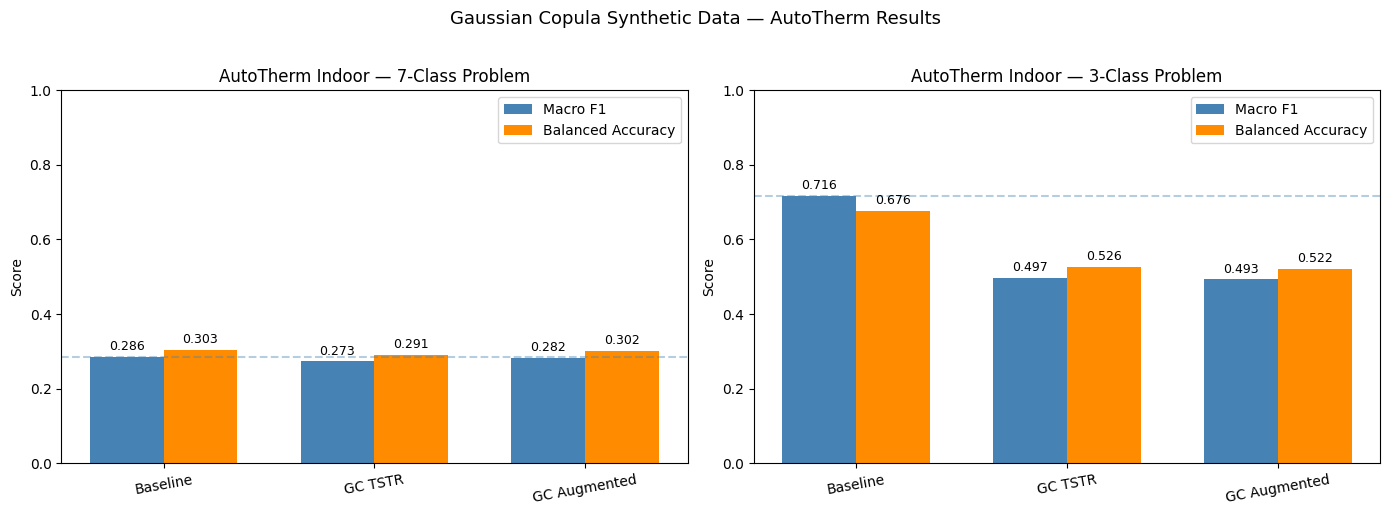

✅ Chart saved!


In [ ]:
# Your complete results table so far
results = pd.DataFrame({
    'Method': [
        'Baseline',
        'GC TSTR',
        'GC Augmented',
    ],
    '7-class Macro F1': [
        base_7_f1, gc_tstr_7_f1, gc_aug_7_f1
    ],
    '7-class Bal Acc': [
        base_7_bal, gc_tstr_7_bal, gc_aug_7_bal
    ],
    '3-class Macro F1': [
        base_3_f1, gc_tstr_3_f1, gc_aug_3_f1
    ],
    '3-class Bal Acc': [
        base_3_bal, gc_tstr_3_bal, gc_aug_3_bal
    ],
}).round(4)

print("=" * 70)
print("FULL RESULTS TABLE — AutoTherm Indoor, Gaussian Copula")
print("=" * 70)
print(results.to_string(index=False))

# Save results
results.to_csv('wk2_gaussiancopula_results.csv', index=False)
print("\n✅ Results saved to wk2_gaussiancopula_results.csv")

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

methods = results['Method']
x = np.arange(len(methods))
w = 0.35

for ax, f1_col, bal_col, title in zip(
    axes,
    ['7-class Macro F1', '3-class Macro F1'],
    ['7-class Bal Acc',  '3-class Bal Acc'],
    ['7-Class Problem',  '3-Class Problem']
):
    b1 = ax.bar(x - w/2, results[f1_col], w, label='Macro F1',         color='steelblue')
    b2 = ax.bar(x + w/2, results[bal_col], w, label='Balanced Accuracy', color='darkorange')
    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=10)
    ax.set_ylim(0, 1.0)
    ax.set_title(f'AutoTherm Indoor — {title}')
    ax.set_ylabel('Score')
    ax.legend()
    ax.axhline(y=results[f1_col][0], color='steelblue',
               linestyle='--', alpha=0.4)
    for bar in list(b1) + list(b2):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=9)

plt.suptitle('Gaussian Copula Synthetic Data — AutoTherm Results',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('wk2_gaussiancopula_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

In [ ]:
results.to_csv('wk2_gaussiancopula_results.csv', index=False)